# Hybrid CT MC vs Distributed IBM Quantum MC — 160Q / 3-QPU Async Version

This notebook reflects two requested changes:

- **160-qubit quantum proposal design**
- **3-way simultaneous distributed execution** with **asynchronous JSONL logging**

### 160-qubit proposal partition
- global latent: **16 qubits**
- patch latent: **128 qubits**
- nuisance/control: **16 qubits**

### 3-way distributed execution
- the 160-qubit circuit is partitioned into **3 subcircuits**
- default split: **54 + 53 + 53 qubits**
- each subcircuit is submitted to a different backend **concurrently**
- each worker logs status, job IDs, repeat index, and counts to JSONL
- after all jobs complete, counts are merged to form the offline quantum bit-pool


In [1]:

# =========================================================
# Block 0. Imports
# =========================================================
from __future__ import annotations

import os
import json
import math
import time
import random
import re
import concurrent.futures
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

try:
    from dotenv import load_dotenv
    HAS_DOTENV = True
except Exception:
    HAS_DOTENV = False

try:
    from qiskit import QuantumCircuit
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Session
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    HAS_RUNTIME = True
except Exception:
    QuantumCircuit = None
    QiskitRuntimeService = None
    SamplerV2 = None
    Session = None
    generate_preset_passmanagers = None
    HAS_RUNTIME = False

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

if HAS_DOTENV:
    load_dotenv()

print("device:", device)
print("HAS_RUNTIME:", HAS_RUNTIME)
print("HAS_DOTENV:", HAS_DOTENV)


device: cuda
HAS_RUNTIME: True
HAS_DOTENV: True


In [2]:

# =========================================================
# Block 1. Configuration
# =========================================================
@dataclass
class ProjectionLoadConfig:
    patient_dir: str = "./C290"
    low_dir: Optional[str] = None
    full_dir: Optional[str] = None
    use_instance_number_sort: bool = True
    collapse_mode: str = "mean"
    row_index: Optional[int] = None
    max_views: int = 360
    detector_bins_out: int = 512
    save_dir: str = "outputs_hybrid_ct_160q_async3"

@dataclass
class GeometryConfig:
    image_size: int = 128

@dataclass
class SamplerConfig:
    global_latent_dim: int = 16
    patch_latent_dim: int = 8
    patch_size: int = 32
    patch_stride: int = 16
    patch_block_latents: int = 12

    num_chains: int = 4
    num_temperatures: int = 2
    steps: int = 12
    burnin: int = 4
    thin: int = 2

    global_step_size: float = 0.005
    patch_step_size: float = 0.003
    global_noise: float = 0.005
    patch_noise: float = 0.003
    proposal_scale: float = 0.03

    nuisance_step_scale: float = 0.005
    nuisance_init: float = 0.01

    lambda_data: float = 1.0
    lambda_prior_global: float = 0.02
    lambda_prior_patch: float = 0.02
    lambda_tv: float = 5e-4

    num_posterior_keep: int = 4
    residual_scale: float = 0.10

    quantum_total_qubits: int = 160
    quantum_global_qubits: int = 16
    quantum_patch_qubits: int = 128
    quantum_nuisance_qubits: int = 16
    quantum_depth: int = 3
    quantum_entanglement: str = "linear"

@dataclass
class RuntimeConfig:
    channel: str = "ibm_cloud"
    instance: Optional[str] = None
    backend_names: Optional[List[str]] = None
    use_saved_account: bool = False
    token_env_var: str = "IBM_QUANTUM_TOKEN"

    subcircuit_sizes: Optional[List[int]] = None
    shots_per_subcircuit: int = 128
    optimization_level: int = 1
    bit_pool_size: int = 256
    max_retries: int = 3
    retry_sleep_sec: int = 5
    logger_jsonl: str = "quantum_exec_log_160q_async3.jsonl"

    session_repeats: int = 8
    session_use_single_backend_per_subcircuit: bool = True
    max_workers: int = 3

load_cfg = ProjectionLoadConfig(
    patient_dir="./C290/01-31-2022-NA-NA-72614",
    save_dir="outputs_hybrid_ct_160q_async3",
)
geom = GeometryConfig()
sampler_cfg = SamplerConfig()

backend_str = os.getenv("IBM_BACKENDS", "")
backend_list = [x.strip() for x in backend_str.split(",") if x.strip()] or None

runtime_cfg = RuntimeConfig(
    channel=os.getenv("IBM_CHANNEL", "ibm_cloud"),
    instance=os.getenv("IBM_QUANTUM_INSTANCE"),
    backend_names=backend_list,
    use_saved_account=False,
    token_env_var="IBM_QUANTUM_TOKEN",
    subcircuit_sizes=[54, 53, 53],
    max_workers=3,
)

Path(load_cfg.save_dir).mkdir(parents=True, exist_ok=True)

print(asdict(load_cfg))
print(asdict(geom))
print(asdict(sampler_cfg))
print(asdict(runtime_cfg))
print("IBM token loaded:", os.getenv(runtime_cfg.token_env_var) is not None)


{'patient_dir': './C290/01-31-2022-NA-NA-72614', 'low_dir': None, 'full_dir': None, 'use_instance_number_sort': True, 'collapse_mode': 'mean', 'row_index': None, 'max_views': 360, 'detector_bins_out': 512, 'save_dir': 'outputs_hybrid_ct_160q_async3'}
{'image_size': 128}
{'global_latent_dim': 16, 'patch_latent_dim': 8, 'patch_size': 32, 'patch_stride': 16, 'patch_block_latents': 12, 'num_chains': 4, 'num_temperatures': 2, 'steps': 12, 'burnin': 4, 'thin': 2, 'global_step_size': 0.005, 'patch_step_size': 0.003, 'global_noise': 0.005, 'patch_noise': 0.003, 'proposal_scale': 0.03, 'nuisance_step_scale': 0.005, 'nuisance_init': 0.01, 'lambda_data': 1.0, 'lambda_prior_global': 0.02, 'lambda_prior_patch': 0.02, 'lambda_tv': 0.0005, 'num_posterior_keep': 4, 'residual_scale': 0.1, 'quantum_total_qubits': 160, 'quantum_global_qubits': 16, 'quantum_patch_qubits': 128, 'quantum_nuisance_qubits': 16, 'quantum_depth': 3, 'quantum_entanglement': 'linear'}
{'channel': 'ibm_cloud', 'instance': 'crn:v1:

## 160Q / 3-QPU Async Design Notes

This version reflects the requested architecture:

### 160-qubit proposal budget
- **16 qubits**: global latent proposal
- **128 qubits**: patch-latent proposal
- **16 qubits**: nuisance/control proposal

### 3-QPU simultaneous execution
- The 160-qubit circuit is partitioned into **3 subcircuits**
- Default split: **54 + 53 + 53 qubits**
- Each subcircuit is submitted to a different backend **concurrently**
- Each worker uses **session-based repeated execution (`session_repeats=8`)**
- Each repeat is logged asynchronously to **JSONL**
- After completion, subcircuit counts are merged and converted into an offline quantum bit-pool


In [3]:

# =========================================================
# Block 2. Path and DICOM helpers
# =========================================================
def numeric_key(path: Path):
    nums = re.findall(r"\d+", path.stem)
    return tuple(int(x) for x in nums) if nums else (path.stem,)

def normalize_image(x: torch.Tensor, eps: float = 1e-8):
    x_min = x.amin(dim=(-2, -1), keepdim=True)
    x_max = x.amax(dim=(-2, -1), keepdim=True)
    return (x - x_min) / (x_max - x_min + eps)

def find_projection_folders(patient_dir: Path):
    low_dir = None
    full_dir = None
    for p in patient_dir.rglob("*"):
        if not p.is_dir():
            continue
        name = p.name.lower()
        if "low dose projections" in name:
            low_dir = p
        elif "full dose projections" in name:
            full_dir = p
    return low_dir, full_dir

def choose_projection_folders(cfg: ProjectionLoadConfig):
    patient_dir = Path(cfg.patient_dir)
    low_dir = Path(cfg.low_dir) if cfg.low_dir else None
    full_dir = Path(cfg.full_dir) if cfg.full_dir else None

    if low_dir is None or (full_dir is None and cfg.full_dir is None):
        auto_low, auto_full = find_projection_folders(patient_dir)
        low_dir = low_dir or auto_low
        full_dir = full_dir or auto_full

    if low_dir is None:
        raise FileNotFoundError("Low Dose Projections folder not found.")
    return low_dir, full_dir

def read_dicom_projection(fp: Path):
    ds = pydicom.dcmread(str(fp), force=True)
    arr = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    arr = arr * slope + intercept
    meta = {
        "file": fp.name,
        "instance_number": getattr(ds, "InstanceNumber", None),
        "rows": int(getattr(ds, "Rows", arr.shape[0])),
        "cols": int(getattr(ds, "Columns", arr.shape[1])),
        "manufacturer": getattr(ds, "Manufacturer", None),
        "series_description": getattr(ds, "SeriesDescription", None),
    }
    return arr, meta

def load_projection_folder(folder: Path, use_instance_number_sort=True):
    files = list(folder.glob("*.dcm"))
    if not files:
        raise FileNotFoundError(f"No DICOM files in {folder}")

    if use_instance_number_sort:
        instance_map = {}
        for fp in files:
            try:
                ds = pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
                instance_map[fp] = getattr(ds, "InstanceNumber", None)
            except Exception:
                instance_map[fp] = None
        files = sorted(files, key=lambda p: (instance_map[p] is None, instance_map[p], numeric_key(p)))
    else:
        files = sorted(files, key=numeric_key)

    projections, meta = [], []
    expected_shape = None
    for fp in files:
        arr, m = read_dicom_projection(fp)
        if expected_shape is None:
            expected_shape = arr.shape
        if arr.shape != expected_shape:
            raise ValueError(f"Shape mismatch: expected {expected_shape}, got {arr.shape} at {fp.name}")
        projections.append(arr)
        meta.append(m)

    return np.stack(projections, axis=0), meta


In [4]:

# =========================================================
# Block 3. Load projection stacks
# =========================================================
low_dir, full_dir = choose_projection_folders(load_cfg)
low_stack, low_meta = load_projection_folder(low_dir, load_cfg.use_instance_number_sort)
full_stack, full_meta = load_projection_folder(full_dir, load_cfg.use_instance_number_sort) if full_dir is not None else (None, None)

print("low_dir:", low_dir)
print("full_dir:", full_dir)
print("low_stack shape:", low_stack.shape)
print("full_stack shape:", None if full_stack is None else full_stack.shape)


low_dir: C290/01-31-2022-NA-NA-72614/1.000000-Low Dose Projections-31855
full_dir: C290/01-31-2022-NA-NA-72614/1.000000-Full Dose Projections-37429
low_stack shape: (8702, 888, 64)
full_stack shape: (8702, 888, 64)


In [5]:

# =========================================================
# Block 4. Sinogram preparation
# =========================================================
def maybe_subsample_views(stack: np.ndarray, max_views: int):
    n = stack.shape[0]
    if n <= max_views:
        return stack
    idx = np.linspace(0, n - 1, max_views).astype(np.int64)
    return stack[idx]

def collapse_projection_stack(stack: np.ndarray, collapse_mode="mean", row_index=None):
    n_views, h, w = stack.shape
    if collapse_mode == "mean":
        return stack.mean(axis=2).astype(np.float32)
    if collapse_mode == "center":
        return stack[:, :, w // 2].astype(np.float32)
    if collapse_mode == "row":
        if row_index is None:
            raise ValueError("row_index required")
        row_index = max(0, min(w - 1, row_index))
        return stack[:, :, row_index].astype(np.float32)
    raise ValueError(f"Unknown collapse_mode: {collapse_mode}")

def resample_sinogram_2d(sino_2d: np.ndarray, detector_bins_out: int):
    x = torch.from_numpy(sino_2d)[None, None, :, :]
    x = F.interpolate(x, size=(x.shape[2], detector_bins_out), mode="bilinear", align_corners=False)
    return x[0, 0].cpu().numpy().astype(np.float32)

def prepare_2d_sinogram(stack: np.ndarray, cfg: ProjectionLoadConfig):
    stack = maybe_subsample_views(stack, cfg.max_views)
    sino = collapse_projection_stack(stack, cfg.collapse_mode, cfg.row_index)
    return resample_sinogram_2d(sino, cfg.detector_bins_out)

low_sino_2d = prepare_2d_sinogram(low_stack, load_cfg)
full_sino_2d = prepare_2d_sinogram(full_stack, load_cfg) if full_stack is not None else None

print("low_sino_2d:", low_sino_2d.shape)
print("full_sino_2d:", None if full_sino_2d is None else full_sino_2d.shape)


low_sino_2d: (360, 512)
full_sino_2d: (360, 512)


In [6]:

# =========================================================
# Block 5. 2D projector and initial recon
# =========================================================
class ParallelBeamProjector(nn.Module):
    def __init__(self, image_size: int, num_angles: int, detector_bins: int):
        super().__init__()
        self.image_size = image_size
        self.detector_bins = detector_bins
        self.register_buffer("angles", torch.linspace(0.0, math.pi, num_angles))

    def _rotate(self, x, angle):
        b, c, h, w = x.shape
        ca = torch.cos(angle); sa = torch.sin(angle)
        theta = torch.tensor([[ca, -sa, 0.0], [sa, ca, 0.0]], device=x.device, dtype=x.dtype).unsqueeze(0).repeat(b, 1, 1)
        grid = F.affine_grid(theta, x.shape, align_corners=False)
        return F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)

    def forward(self, x):
        projs = []
        for angle in self.angles.to(x.device):
            xr = self._rotate(x, angle)
            p = xr.sum(dim=2)
            if p.shape[-1] != self.detector_bins:
                p = F.interpolate(p, size=self.detector_bins, mode="linear", align_corners=False)
            projs.append(p.unsqueeze(2))
        return torch.cat(projs, dim=2)

    def backproject(self, sino):
        b, c, a, d = sino.shape
        h = w = self.image_size
        out = torch.zeros((b, 1, h, w), device=sino.device, dtype=sino.dtype)
        for i, angle in enumerate(self.angles.to(sino.device)):
            p = sino[:, :, i, :]
            if d != w:
                p = F.interpolate(p, size=w, mode="linear", align_corners=False)
            strip = p.unsqueeze(2).repeat(1, 1, h, 1)
            ca = torch.cos(-angle); sa = torch.sin(-angle)
            theta = torch.tensor([[ca, -sa, 0.0], [sa, ca, 0.0]], device=sino.device, dtype=sino.dtype).unsqueeze(0).repeat(b, 1, 1)
            grid = F.affine_grid(theta, strip.shape, align_corners=False)
            out += F.grid_sample(strip, grid, mode="bilinear", padding_mode="zeros", align_corners=False)
        return out / max(1, a)

num_angles, detector_bins = low_sino_2d.shape
projector = ParallelBeamProjector(geom.image_size, num_angles, detector_bins).to(device)

low_sino_t = torch.from_numpy(low_sino_2d).float().unsqueeze(0).unsqueeze(0).to(device)
x0 = normalize_image(projector.backproject(low_sino_t))

full_sino_t = torch.from_numpy(full_sino_2d).float().unsqueeze(0).unsqueeze(0).to(device) if full_sino_2d is not None else None
x_ref = normalize_image(projector.backproject(full_sino_t)) if full_sino_t is not None else None

print("x0:", tuple(x0.shape))
print("x_ref:", None if x_ref is None else tuple(x_ref.shape))


x0: (1, 1, 128, 128)
x_ref: (1, 1, 128, 128)


In [7]:

# =========================================================
# Block 6. Latent decoders and patch helpers
# =========================================================
class GlobalDecoder(nn.Module):
    def __init__(self, latent_dim: int, image_size: int):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.SiLU(),
            nn.Linear(256, image_size * image_size),
        )
        self.image_size = image_size

    def forward(self, z):
        return self.fc(z).view(z.shape[0], 1, self.image_size, self.image_size)

class PatchDictionaryDecoder(nn.Module):
    def __init__(self, patch_latent_dim: int, patch_size: int):
        super().__init__()
        self.weight = nn.Parameter(0.05 * torch.randn(patch_latent_dim, patch_size * patch_size))

    def forward(self, z_patch):
        return torch.einsum("bld,dk->blk", z_patch, self.weight)

def extract_patches(x, patch_size, stride):
    unfolded = F.unfold(x, kernel_size=patch_size, stride=stride)
    patches = unfolded.transpose(1, 2)
    return patches, patches.shape[1]

def _make_2d_hann_window(patch_size: int, device, dtype):
    w1 = torch.hann_window(patch_size, periodic=False, device=device, dtype=dtype)
    w2 = torch.outer(w1, w1)
    w2 = w2 / (w2.max() + 1e-8)
    return w2.reshape(1, 1, patch_size, patch_size)

def fold_patches(patches, output_size, patch_size, stride):
    b, l, k = patches.shape
    device = patches.device
    dtype = patches.dtype

    window = _make_2d_hann_window(patch_size, device, dtype).reshape(1, -1, 1)
    weighted = patches.transpose(1, 2) * window

    out = F.fold(weighted, output_size=output_size, kernel_size=patch_size, stride=stride)

    ones = torch.ones((b, 1, output_size[0], output_size[1]), device=device, dtype=dtype)
    ones_unfold = F.unfold(ones, kernel_size=patch_size, stride=stride)
    norm = F.fold(ones_unfold * window, output_size=output_size, kernel_size=patch_size, stride=stride)

    return out / (norm + 1e-6)

def tv_loss(x):
    return (x[..., 1:, :] - x[..., :-1, :]).abs().mean() + (x[..., :, 1:] - x[..., :, :-1]).abs().mean()

global_decoder = GlobalDecoder(sampler_cfg.global_latent_dim, geom.image_size).to(device)
patch_decoder = PatchDictionaryDecoder(sampler_cfg.patch_latent_dim, sampler_cfg.patch_size).to(device)

_, num_patches = extract_patches(x0, sampler_cfg.patch_size, sampler_cfg.patch_stride)
print("num_patches:", num_patches)
print("global_decoder ready")
print("patch_decoder ready")


num_patches: 49
global_decoder ready
patch_decoder ready


In [8]:

# =========================================================
# Block 7. Logging and proposal assistants
# =========================================================
class JSONLLogger:
    def __init__(self, path: Path):
        self.path = Path(path)
        self.path.parent.mkdir(parents=True, exist_ok=True)

    def log(self, record: dict):
        with self.path.open("a", encoding="utf-8") as f:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

class ClassicalProposalAssistant:
    def __init__(self, cfg: SamplerConfig):
        self.cfg = cfg

    def sample_partitioned(self, batch_size: int, device: str = "cpu"):
        g = 2.0 * torch.randint(0, 2, (batch_size, self.cfg.quantum_global_qubits), device=device).float() - 1.0
        p = 2.0 * torch.randint(0, 2, (batch_size, self.cfg.quantum_patch_qubits), device=device).float() - 1.0
        n = 2.0 * torch.randint(0, 2, (batch_size, self.cfg.quantum_nuisance_qubits), device=device).float() - 1.0
        return {"global_bits": g, "patch_bits": p, "nuisance_bits": n}

class DistributedCuttingQuantumProposalAssistant160:
    def __init__(self, sampler_cfg: SamplerConfig, runtime_cfg: RuntimeConfig, save_dir: str, seed: int = 42):
        self.cfg = sampler_cfg
        self.runtime_cfg = runtime_cfg
        self.seed = seed
        self.use_quantum = HAS_RUNTIME and (os.getenv(runtime_cfg.token_env_var) is not None or runtime_cfg.use_saved_account)
        self.service = None
        self.backends = []
        self.logger = JSONLLogger(Path(save_dir) / runtime_cfg.logger_jsonl)

        self.bit_pool = None
        self.bit_pool_index = 0
        self.last_distributed_results = None

        assert (
            sampler_cfg.quantum_global_qubits
            + sampler_cfg.quantum_patch_qubits
            + sampler_cfg.quantum_nuisance_qubits
            == sampler_cfg.quantum_total_qubits
        )

        self.sub_sizes = runtime_cfg.subcircuit_sizes or [54, 53, 53]
        assert sum(self.sub_sizes) == sampler_cfg.quantum_total_qubits
        assert len(self.sub_sizes) == 3

        if not self.use_quantum:
            print("Quantum runtime disabled or token missing. Falling back to random pool.")
            return

        if runtime_cfg.use_saved_account:
            if runtime_cfg.instance:
                self.service = QiskitRuntimeService(channel=runtime_cfg.channel, instance=runtime_cfg.instance)
            else:
                self.service = QiskitRuntimeService(channel=runtime_cfg.channel)
        else:
            token = os.environ.get(runtime_cfg.token_env_var)
            if runtime_cfg.instance:
                self.service = QiskitRuntimeService(channel=runtime_cfg.channel, token=token, instance=runtime_cfg.instance)
            else:
                self.service = QiskitRuntimeService(channel=runtime_cfg.channel, token=token)

        if runtime_cfg.backend_names:
            self.backends = [self.service.backend(name) for name in runtime_cfg.backend_names[:3]]
            while len(self.backends) < 3:
                self.backends.append(self.backends[-1])
        else:
            selected = self.service.least_busy(operational=True, simulator=False)
            self.backends = [selected, selected, selected]

        print("Using backends:", [b.name for b in self.backends])

    def _build_160q_circuit(self):
        n = self.cfg.quantum_total_qubits
        qc = QuantumCircuit(n, n)
        for q in range(n):
            qc.h(q)

        ranges = self._qubit_ranges()
        for layer in range(self.cfg.quantum_depth):
            for q in range(n):
                qc.ry(0.1 * (layer + 1) * ((q % 7) + 1), q)
            for start, end in ranges:
                for q in range(start, end - 1):
                    qc.cx(q, q + 1)

        qc.measure(range(n), range(n))
        return qc

    def _qubit_ranges(self):
        out = []
        cur = 0
        for sz in self.sub_sizes:
            out.append((cur, cur + sz))
            cur += sz
        return out

    def generate_subcircuits(self, circuit: QuantumCircuit, qubit_ranges: List[Tuple[int, int]]):
        subcircuits = []
        for start, end in qubit_ranges:
            qc = QuantumCircuit(end - start, end - start)
            for instruction in circuit.data:
                inst = instruction.operation
                qargs = instruction.qubits
                q_indices = []
                valid = True
                for qarg in qargs:
                    q_idx = circuit.find_bit(qarg).index
                    q_indices.append(q_idx)
                    if q_idx < start or q_idx >= end:
                        valid = False
                        break
                if valid and inst.name != "measure":
                    new_qargs = [q_idx - start for q_idx in q_indices]
                    qc.append(inst, new_qargs, [])
            qc.measure(range(end - start), range(end - start))
            subcircuits.append(qc)
        return subcircuits

    def _extract_counts(self, pub_result):
        data = getattr(pub_result, "data", None)
        if data is None:
            return {}
        if hasattr(data, "meas"):
            try:
                return data.meas.get_counts()
            except Exception:
                pass
        if hasattr(data, "c"):
            try:
                return data.c.get_counts()
            except Exception:
                pass
        return {}

    def _merge_counts(self, acc: dict, new_counts: dict):
        merged = dict(acc)
        for k, v in (new_counts or {}).items():
            merged[k] = merged.get(k, 0) + int(v)
        return merged

    def execute_single_subcircuit(self, circuit: QuantumCircuit, backend, shots: int, subcircuit_id: int):
        record = {
            "subcircuit_id": subcircuit_id,
            "backend": backend.name,
            "shots": shots,
            "session_repeats": self.runtime_cfg.session_repeats,
            "status": "started",
            "job_ids": [],
            "counts": {},
            "error": None,
            "completed_repeats": 0,
        }

        try:
            pm = generate_preset_pass_manager(
                optimization_level=self.runtime_cfg.optimization_level,
                backend=backend,
            )
            transpiled = pm.run(circuit)

            last_err = None
            merged_counts = {}

            with Session(backend=backend) as session:
                sampler = SamplerV2(mode=session)
                for rep in range(self.runtime_cfg.session_repeats):
                    rep_success = False
                    for attempt in range(self.runtime_cfg.max_retries):
                        try:
                            job = sampler.run([(transpiled,)], shots=shots)
                            record["job_ids"].append(job.job_id())
                            result = job.result()
                            counts = self._extract_counts(result[0])
                            merged_counts = self._merge_counts(merged_counts, counts)
                            record["completed_repeats"] += 1
                            rep_success = True
                            self.logger.log({
                                **record,
                                "status": "repeat_completed",
                                "repeat_index": rep,
                                "counts_size": len(counts),
                            })
                            break
                        except Exception as e:
                            last_err = str(e)
                            self.logger.log({
                                **record,
                                "status": "repeat_retrying",
                                "repeat_index": rep,
                                "attempt": attempt + 1,
                                "error": last_err,
                            })
                            time.sleep(self.runtime_cfg.retry_sleep_sec * (attempt + 1))
                    if not rep_success:
                        self.logger.log({
                            **record,
                            "status": "repeat_failed_fallback",
                            "repeat_index": rep,
                            "error": last_err,
                        })

            record["counts"] = merged_counts
            record["status"] = "completed" if record["completed_repeats"] > 0 else "failed"
            record["error"] = None if record["completed_repeats"] > 0 else last_err
            self.logger.log(record)
            return record
        except Exception as e:
            record["status"] = "failed"
            record["error"] = str(e)
            self.logger.log(record)
            return record

    def execute_distributed(self, circuit: QuantumCircuit):
        qubit_ranges = self._qubit_ranges()
        subcircuits = self.generate_subcircuits(circuit, qubit_ranges)
        results = [None] * len(subcircuits)

        with concurrent.futures.ThreadPoolExecutor(max_workers=self.runtime_cfg.max_workers) as executor:
            future_to_idx = {}
            for i, subcircuit in enumerate(subcircuits):
                backend = self.backends[i % len(self.backends)] if self.backends else None
                if backend is None:
                    results[i] = {
                        "subcircuit_id": i,
                        "backend": None,
                        "shots": self.runtime_cfg.shots_per_subcircuit,
                        "session_repeats": self.runtime_cfg.session_repeats,
                        "status": "fallback",
                        "counts": {},
                        "job_ids": [],
                        "completed_repeats": 0,
                        "error": "No backend available",
                    }
                else:
                    fut = executor.submit(
                        self.execute_single_subcircuit,
                        subcircuit,
                        backend,
                        self.runtime_cfg.shots_per_subcircuit,
                        i,
                    )
                    future_to_idx[fut] = i

            for fut in concurrent.futures.as_completed(future_to_idx):
                idx = future_to_idx[fut]
                try:
                    results[idx] = fut.result()
                except Exception as e:
                    results[idx] = {
                        "subcircuit_id": idx,
                        "backend": self.backends[idx % len(self.backends)].name if self.backends else None,
                        "shots": self.runtime_cfg.shots_per_subcircuit,
                        "session_repeats": self.runtime_cfg.session_repeats,
                        "status": "failed",
                        "counts": {},
                        "job_ids": [],
                        "completed_repeats": 0,
                        "error": str(e),
                    }
                    self.logger.log(results[idx])

        self.last_distributed_results = results
        return results

    def reconstruct_distributed_bitstring(self, distributed_results, n_samples: int):
        bitstrings_per_sub = []
        for sub_idx, r in enumerate(distributed_results):
            counts = r.get("counts", {}) or {}
            block = self.sub_sizes[sub_idx]
            if not counts:
                samples = np.random.randint(0, 2, size=(n_samples, block), dtype=np.int64)
            else:
                population, weights = [], []
                for k, v in counts.items():
                    bitstr = str(k).replace(" ", "")
                    if len(bitstr) < block:
                        bitstr = bitstr.zfill(block)
                    population.append(bitstr[-block:])
                    weights.append(v)
                weights = np.array(weights, dtype=np.float64)
                weights = weights / weights.sum()
                chosen = np.random.choice(len(population), size=n_samples, p=weights)
                samples = np.stack([
                    np.array([1 if ch == "1" else 0 for ch in population[idx]], dtype=np.int64)
                    for idx in chosen
                ], axis=0)
            bitstrings_per_sub.append(samples)

        full_bits = np.concatenate(bitstrings_per_sub, axis=1)
        return full_bits[:, :self.cfg.quantum_total_qubits]

    def prepare_bit_pool(self, n_samples: Optional[int] = None):
        n_samples = n_samples or self.runtime_cfg.bit_pool_size
        if not self.use_quantum:
            self.bit_pool = np.random.randint(0, 2, size=(n_samples, self.cfg.quantum_total_qubits), dtype=np.int64)
            self.bit_pool_index = 0
            return

        circuit = self._build_160q_circuit()
        distributed_results = self.execute_distributed(circuit)
        self.bit_pool = self.reconstruct_distributed_bitstring(distributed_results, n_samples=n_samples)
        self.bit_pool_index = 0

    def sample_partitioned(self, batch_size: int, device: str = "cpu"):
        if self.bit_pool is None or self.bit_pool_index + batch_size > len(self.bit_pool):
            self.prepare_bit_pool(max(self.runtime_cfg.bit_pool_size, batch_size))

        bits = self.bit_pool[self.bit_pool_index:self.bit_pool_index + batch_size]
        self.bit_pool_index += batch_size

        bits = bits.astype(np.float32)
        bits = 2.0 * bits - 1.0

        g1 = self.cfg.quantum_global_qubits
        p1 = g1 + self.cfg.quantum_patch_qubits
        return {
            "global_bits": torch.tensor(bits[:, :g1], dtype=torch.float32, device=device),
            "patch_bits": torch.tensor(bits[:, g1:p1], dtype=torch.float32, device=device),
            "nuisance_bits": torch.tensor(bits[:, p1:], dtype=torch.float32, device=device),
        }

classical_assist = ClassicalProposalAssistant(sampler_cfg)
quantum_assist = DistributedCuttingQuantumProposalAssistant160(sampler_cfg, runtime_cfg, load_cfg.save_dir, seed=42)

print("classical_assist ready")
print("quantum_assist ready")


qiskit_runtime_service._discover_account:WARNING:2026-03-13 14:58:17,331: Loading account with the given token. A saved account will not be used.


Using backends: ['ibm_marrakesh', 'ibm_torino', 'ibm_miami']
classical_assist ready
quantum_assist ready


In [9]:

# =========================================================
# Block 8. Reconstruction helpers and energy model
# =========================================================
def choose_patch_block(num_patches: int, block_size: int, step: int):
    start = (step * block_size) % num_patches
    return (np.arange(start, start + block_size) % num_patches).astype(np.int64)

def bits_to_global_latent(bits, latent_dim, scale):
    return scale * bits[:, :latent_dim]

def bits_to_patch_block(bits, block_latents, patch_latent_dim, scale):
    need = block_latents * patch_latent_dim
    b = bits[:, :need]
    return scale * b.view(bits.shape[0], block_latents, patch_latent_dim)

def bits_to_nuisance(bits, scale):
    return scale * bits.mean(dim=1)

def reconstruct_from_latents(x0, z_global, z_patch, global_decoder, patch_decoder, patch_size, patch_stride, residual_scale=0.10):
    g_res = global_decoder(z_global)
    patch_res_flat = patch_decoder(z_patch)
    patch_res = fold_patches(patch_res_flat, (x0.shape[-2], x0.shape[-1]), patch_size, patch_stride)
    residual = residual_scale * (g_res + patch_res)
    return torch.clamp(x0 + residual, 0.0, 1.0)

def forward_with_nuisance(x, projector, beta):
    base = projector(x)
    return base + beta.view(-1, 1, 1, 1) * (base ** 2)

def energy_fn(x, sino, projector, z_global, z_patch, beta, cfg):
    pred = forward_with_nuisance(x, projector, beta)
    data_term = cfg.lambda_data * ((pred - sino) ** 2).mean(dim=(1, 2, 3))
    prior_g = cfg.lambda_prior_global * (z_global ** 2).mean(dim=1)
    prior_p = cfg.lambda_prior_patch * (z_patch ** 2).mean(dim=(1, 2))
    tv_term = cfg.lambda_tv * torch.stack([tv_loss(x[i:i+1]) for i in range(x.shape[0])])
    return data_term + prior_g + prior_p + tv_term

@torch.no_grad()
def mh_within_gibbs_beta(x, sino, projector, z_global, z_patch, beta, temperature, cfg):
    current_e = energy_fn(x, sino, projector, z_global, z_patch, beta, cfg) / temperature
    proposal = torch.clamp(beta + cfg.nuisance_step_scale * torch.randn_like(beta), -0.2, 0.2)
    prop_e = energy_fn(x, sino, projector, z_global, z_patch, proposal, cfg) / temperature
    log_alpha = -(prop_e - current_e)
    accept = (torch.log(torch.rand_like(log_alpha)) < log_alpha).float()
    beta_new = accept * proposal + (1.0 - accept) * beta
    return beta_new, accept.mean()


In [10]:

# =========================================================
# Block 9. Posterior sampler
# =========================================================
class HybridPosteriorSampler:
    def __init__(self, projector, global_decoder, patch_decoder, proposal_assist, geom, cfg, device="cpu"):
        self.projector = projector
        self.global_decoder = global_decoder
        self.patch_decoder = patch_decoder
        self.proposal_assist = proposal_assist
        self.geom = geom
        self.cfg = cfg
        self.device = device

    def _init_states(self, x0):
        _, L = extract_patches(x0, self.cfg.patch_size, self.cfg.patch_stride)
        n = self.cfg.num_chains
        z_global = 0.05 * torch.randn(n, self.cfg.global_latent_dim, device=self.device)
        z_patch = 0.05 * torch.randn(n, L, self.cfg.patch_latent_dim, device=self.device)
        beta = torch.full((n,), self.cfg.nuisance_init, device=self.device)
        temps = torch.linspace(1.8, 1.0, self.cfg.num_temperatures, device=self.device)
        temperature = temps.repeat_interleave(math.ceil(n / self.cfg.num_temperatures))[:n]
        return z_global, z_patch, beta, temperature

    def _reconstruct_batch(self, x0, z_global, z_patch):
        x0_rep = x0.repeat(z_global.shape[0], 1, 1, 1)
        return reconstruct_from_latents(
            x0_rep, z_global, z_patch,
            self.global_decoder, self.patch_decoder,
            self.cfg.patch_size, self.cfg.patch_stride,
            residual_scale=self.cfg.residual_scale
        )

    def _global_pmala_step(self, x0, sino, z_global, z_patch, beta, temperature):
        zg = z_global.clone().detach().requires_grad_(True)
        x = self._reconstruct_batch(x0, zg, z_patch.detach())
        e = energy_fn(x, sino.repeat(zg.shape[0], 1, 1, 1), self.projector, zg, z_patch.detach(), beta, self.cfg) / temperature
        grad = torch.autograd.grad(e.sum(), zg)[0]
        qparts = self.proposal_assist.sample_partitioned(batch_size=zg.shape[0], device=self.device)
        q_global = bits_to_global_latent(qparts["global_bits"], self.cfg.global_latent_dim, self.cfg.proposal_scale)

        proposal = (
            zg
            - self.cfg.global_step_size * grad
            + self.cfg.global_noise * torch.randn_like(zg)
            + q_global
        ).detach()

        x_prop = self._reconstruct_batch(x0, proposal, z_patch.detach())
        e_prop = energy_fn(x_prop, sino.repeat(proposal.shape[0], 1, 1, 1), self.projector, proposal, z_patch.detach(), beta, self.cfg) / temperature
        log_alpha = -(e_prop - e.detach())
        accept = (torch.log(torch.rand_like(log_alpha)) < log_alpha).float()
        z_new = accept[:, None] * proposal + (1.0 - accept[:, None]) * z_global
        return z_new.detach(), float(accept.mean().item())

    def _patch_block_langevin(self, x0, sino, z_global, z_patch, beta, temperature, step_idx):
        zp = z_patch.clone().detach().requires_grad_(True)
        x = self._reconstruct_batch(x0, z_global.detach(), zp)
        e = energy_fn(x, sino.repeat(zp.shape[0], 1, 1, 1), self.projector, z_global.detach(), zp, beta, self.cfg) / temperature
        grad = torch.autograd.grad(e.sum(), zp)[0]

        zp_new = zp.detach().clone()
        block_idx = choose_patch_block(zp.shape[1], self.cfg.patch_block_latents, step_idx)

        qparts = self.proposal_assist.sample_partitioned(batch_size=zp.shape[0], device=self.device)
        q_patch = bits_to_patch_block(
            qparts["patch_bits"],
            self.cfg.patch_block_latents,
            self.cfg.patch_latent_dim,
            self.cfg.proposal_scale * 0.5
        )

        idx_t = torch.tensor(block_idx, device=zp.device, dtype=torch.long)
        grad_block = grad[:, idx_t, :]
        zp_new[:, idx_t, :] = (
            zp_new[:, idx_t, :]
            - self.cfg.patch_step_size * grad_block
            + self.cfg.patch_noise * torch.randn_like(grad_block)
            + q_patch
        )
        return zp_new.detach()

    @torch.no_grad()
    def _temperature_swap(self, z_global, z_patch, beta, energies, temperature):
        swaps = 0
        for i in range(0, z_global.shape[0] - 1, 2):
            log_alpha = (1.0 / temperature[i] - 1.0 / temperature[i + 1]) * (energies[i] - energies[i + 1])
            if torch.log(torch.rand(1, device=z_global.device)) < log_alpha:
                z_global[[i, i+1]] = z_global[[i+1, i]]
                z_patch[[i, i+1]] = z_patch[[i+1, i]]
                beta[[i, i+1]] = beta[[i+1, i]]
                swaps += 1
        return z_global, z_patch, beta, swaps

    def run(self, x0, sino):
        z_global, z_patch, beta, temperature = self._init_states(x0)
        keep = []
        trace = {"global_accept": [], "beta_accept": [], "swaps": [], "beta_mean": [], "energy_mean": []}

        for step in range(self.cfg.steps):
            z_global, g_acc = self._global_pmala_step(x0, sino, z_global, z_patch, beta, temperature)
            z_patch = self._patch_block_langevin(x0, sino, z_global, z_patch, beta, temperature, step)

            x = self._reconstruct_batch(x0, z_global, z_patch)
            qparts = self.proposal_assist.sample_partitioned(batch_size=beta.shape[0], device=self.device)
            beta_seed = beta + bits_to_nuisance(qparts["nuisance_bits"], self.cfg.nuisance_step_scale)
            beta, b_acc = mh_within_gibbs_beta(
                x, sino.repeat(x.shape[0], 1, 1, 1), self.projector,
                z_global, z_patch, beta_seed, temperature, self.cfg
            )

            x = self._reconstruct_batch(x0, z_global, z_patch)
            e = energy_fn(x, sino.repeat(x.shape[0], 1, 1, 1), self.projector, z_global, z_patch, beta, self.cfg)
            z_global, z_patch, beta, swaps = self._temperature_swap(z_global, z_patch, beta, e.detach(), temperature)

            trace["global_accept"].append(g_acc)
            trace["beta_accept"].append(float(b_acc.item() if hasattr(b_acc, "item") else b_acc))
            trace["swaps"].append(swaps)
            trace["beta_mean"].append(float(beta.mean().item()))
            trace["energy_mean"].append(float(e.mean().item()))

            if step >= self.cfg.burnin and ((step - self.cfg.burnin) % self.cfg.thin == 0):
                cold_idx = torch.argmin(temperature)
                keep.append({
                    "x": x[cold_idx:cold_idx+1].detach().cpu(),
                    "beta": beta[cold_idx:cold_idx+1].detach().cpu(),
                    "energy": e[cold_idx:cold_idx+1].detach().cpu(),
                })

        keep = keep[-self.cfg.num_posterior_keep:]
        return {
            "samples": torch.cat([k["x"] for k in keep], dim=0),
            "betas": torch.cat([k["beta"] for k in keep], dim=0),
            "energies": torch.cat([k["energy"] for k in keep], dim=0),
            "trace": trace,
        }


In [11]:

# =========================================================
# Block 10. Run samplers
# =========================================================
print("projector:", "ok" if "projector" in globals() else "missing")
print("global_decoder:", "ok" if "global_decoder" in globals() else "missing")
print("patch_decoder:", "ok" if "patch_decoder" in globals() else "missing")
print("classical_assist:", "ok" if "classical_assist" in globals() else "missing")
print("quantum_assist:", "ok" if "quantum_assist" in globals() else "missing")

classical_sampler = HybridPosteriorSampler(projector, global_decoder, patch_decoder, classical_assist, geom, sampler_cfg, device=device)
quantum_sampler = HybridPosteriorSampler(projector, global_decoder, patch_decoder, quantum_assist, geom, sampler_cfg, device=device)

quantum_assist.prepare_bit_pool(runtime_cfg.bit_pool_size)

classical_results = classical_sampler.run(x0, low_sino_t)
quantum_results = quantum_sampler.run(x0, low_sino_t)

print("classical samples:", classical_results["samples"].shape)
print("quantum samples:", quantum_results["samples"].shape)


projector: ok
global_decoder: ok
patch_decoder: ok
classical_assist: ok
quantum_assist: ok
classical samples: torch.Size([4, 1, 128, 128])
quantum samples: torch.Size([4, 1, 128, 128])


In [12]:

# =========================================================
# Block 11. Posterior summaries
# =========================================================
def posterior_summary(samples):
    return {
        "mean": samples.mean(dim=0, keepdim=True),
        "var": samples.var(dim=0, unbiased=False, keepdim=True),
        "q05": torch.quantile(samples, 0.05, dim=0, keepdim=True),
        "q95": torch.quantile(samples, 0.95, dim=0, keepdim=True),
    }

classical_samples = classical_results["samples"]
quantum_samples = quantum_results["samples"]
classical_betas = classical_results["betas"]
quantum_betas = quantum_results["betas"]
classical_energies = classical_results["energies"]
quantum_energies = quantum_results["energies"]
classical_trace = classical_results["trace"]
quantum_trace = quantum_results["trace"]

classical_summary = posterior_summary(classical_samples.to(device))
quantum_summary = posterior_summary(quantum_samples.to(device))

classical_condition = torch.cat([x0, classical_summary["mean"], classical_summary["var"], classical_summary["q05"], classical_summary["q95"]], dim=1)
quantum_condition = torch.cat([x0, quantum_summary["mean"], quantum_summary["var"], quantum_summary["q05"], quantum_summary["q95"]], dim=1)


In [13]:

# =========================================================
# Block 12. Refiners
# =========================================================
class SimpleRefiner(nn.Module):
    def __init__(self, in_ch=5, hidden=32):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(in_ch, hidden, 3, padding=1), nn.SiLU())
        self.enc2 = nn.Sequential(nn.Conv2d(hidden, hidden, 3, stride=2, padding=1), nn.SiLU())
        self.bot = nn.Sequential(nn.Conv2d(hidden, hidden, 3, padding=1), nn.SiLU())
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1), nn.SiLU())
        self.out = nn.Conv2d(hidden, 1, 3, padding=1)

    def forward(self, x):
        h1 = self.enc1(x); h2 = self.enc2(h1); hb = self.bot(h2); hd = self.dec1(hb)
        return torch.clamp(x[:, :1] + 0.25 * self.out(hd + h1), 0.0, 1.0)

classical_refiner = SimpleRefiner(in_ch=classical_condition.shape[1]).to(device)
with torch.no_grad():
    x_classical_refined = classical_refiner(classical_condition)

class PatchGenerator(nn.Module):
    def __init__(self, in_ch, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1), nn.SiLU(),
            nn.Conv2d(hidden, hidden, 3, padding=1), nn.SiLU(),
            nn.Conv2d(hidden, 1, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)

class QuantumParallelPatchRefinementGAN(nn.Module):
    def __init__(self, condition_ch, patch_size, stride, proposal_assist, cfg):
        super().__init__()
        self.patch_size = patch_size
        self.stride = stride
        self.proposal_assist = proposal_assist
        self.cfg = cfg
        self.generator = PatchGenerator(condition_ch, hidden=32)

    def _quantum_patch_gates(self, num_patches, device):
        qparts = self.proposal_assist.sample_partitioned(batch_size=1, device=device)
        bits = qparts["patch_bits"].flatten()
        if bits.numel() < num_patches:
            reps = int(math.ceil(num_patches / bits.numel()))
            bits = bits.repeat(reps)
        return torch.sigmoid(0.5 * bits[:num_patches])

    def forward(self, cond):
        b, c, h, w = cond.shape
        patches = F.unfold(cond, kernel_size=self.patch_size, stride=self.stride)
        L = patches.shape[-1]
        patch_cond = patches.transpose(1, 2).reshape(b * L, c, self.patch_size, self.patch_size)
        patch_res = self.generator(patch_cond)
        patch_res_flat = patch_res.reshape(b, L, -1)
        gates = self._quantum_patch_gates(L, cond.device).view(1, L, 1)
        patch_res_flat = 0.25 * patch_res_flat * gates
        refined_res = fold_patches(patch_res_flat, (h, w), self.patch_size, self.stride)
        return torch.clamp(cond[:, :1] + refined_res, 0.0, 1.0), gates.view(1, L)

quantum_patch_gan = QuantumParallelPatchRefinementGAN(
    condition_ch=quantum_condition.shape[1],
    patch_size=sampler_cfg.patch_size,
    stride=sampler_cfg.patch_stride,
    proposal_assist=quantum_assist,
    cfg=sampler_cfg,
).to(device)

with torch.no_grad():
    x_quantum_patch_refined, q_patch_gates = quantum_patch_gan(quantum_condition)


In [14]:

# =========================================================
# Block 13. Metrics
# =========================================================
def mse(x, y):
    return float(torch.mean((x - y) ** 2).item())

def rmse(x, y):
    return float(torch.sqrt(torch.mean((x - y) ** 2)).item())

def psnr(x, y, data_range=1.0):
    m = mse(x, y)
    return 99.0 if m <= 1e-12 else float(20.0 * math.log10(data_range) - 10.0 * math.log10(m))

def ssim_global(x, y, data_range=1.0):
    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    ux, uy = torch.mean(x), torch.mean(y)
    vx, vy = torch.var(x, unbiased=False), torch.var(y, unbiased=False)
    vxy = torch.mean((x - ux) * (y - uy))
    num = (2 * ux * uy + c1) * (2 * vxy + c2)
    den = (ux ** 2 + uy ** 2 + c1) * (vx + vy + c2)
    return float((num / (den + 1e-12)).item())

metrics = {
    "beta_mean_classical": float(classical_betas.mean().item()),
    "beta_mean_quantum_distributed": float(quantum_betas.mean().item()),
    "energy_mean_classical": float(classical_energies.mean().item()),
    "energy_mean_quantum_distributed": float(quantum_energies.mean().item()),
    "uncertainty_mean_classical": float(classical_summary["var"].mean().item()),
    "uncertainty_mean_quantum_distributed": float(quantum_summary["var"].mean().item()),
}

if x_ref is not None:
    metrics.update({
        "initial_rmse_vs_full": rmse(x0, x_ref),
        "initial_psnr_vs_full": psnr(x0, x_ref),
        "initial_ssim_vs_full": ssim_global(x0, x_ref),

        "classical_refined_rmse_vs_full": rmse(x_classical_refined, x_ref),
        "classical_refined_psnr_vs_full": psnr(x_classical_refined, x_ref),
        "classical_refined_ssim_vs_full": ssim_global(x_classical_refined, x_ref),

        "quantum_patch_refined_rmse_vs_full": rmse(x_quantum_patch_refined, x_ref),
        "quantum_patch_refined_psnr_vs_full": psnr(x_quantum_patch_refined, x_ref),
        "quantum_patch_refined_ssim_vs_full": ssim_global(x_quantum_patch_refined, x_ref),
    })

metrics


{'beta_mean_classical': 0.002599169500172138,
 'beta_mean_quantum_distributed': -0.00654575414955616,
 'energy_mean_classical': 3388.418701171875,
 'energy_mean_quantum_distributed': 1311.0960693359375,
 'uncertainty_mean_classical': 3.1518749210590613e-07,
 'uncertainty_mean_quantum_distributed': 2.597626007627696e-07,
 'initial_rmse_vs_full': 0.0025143390521407127,
 'initial_psnr_vs_full': 51.99152319371678,
 'initial_ssim_vs_full': 0.9999775886535645,
 'classical_refined_rmse_vs_full': 0.011343498714268208,
 'classical_refined_psnr_vs_full': 38.905059541648185,
 'classical_refined_ssim_vs_full': 0.9997491240501404,
 'quantum_patch_refined_rmse_vs_full': 0.005054639186710119,
 'quantum_patch_refined_psnr_vs_full': 45.926196403774,
 'quantum_patch_refined_ssim_vs_full': 0.999884307384491}

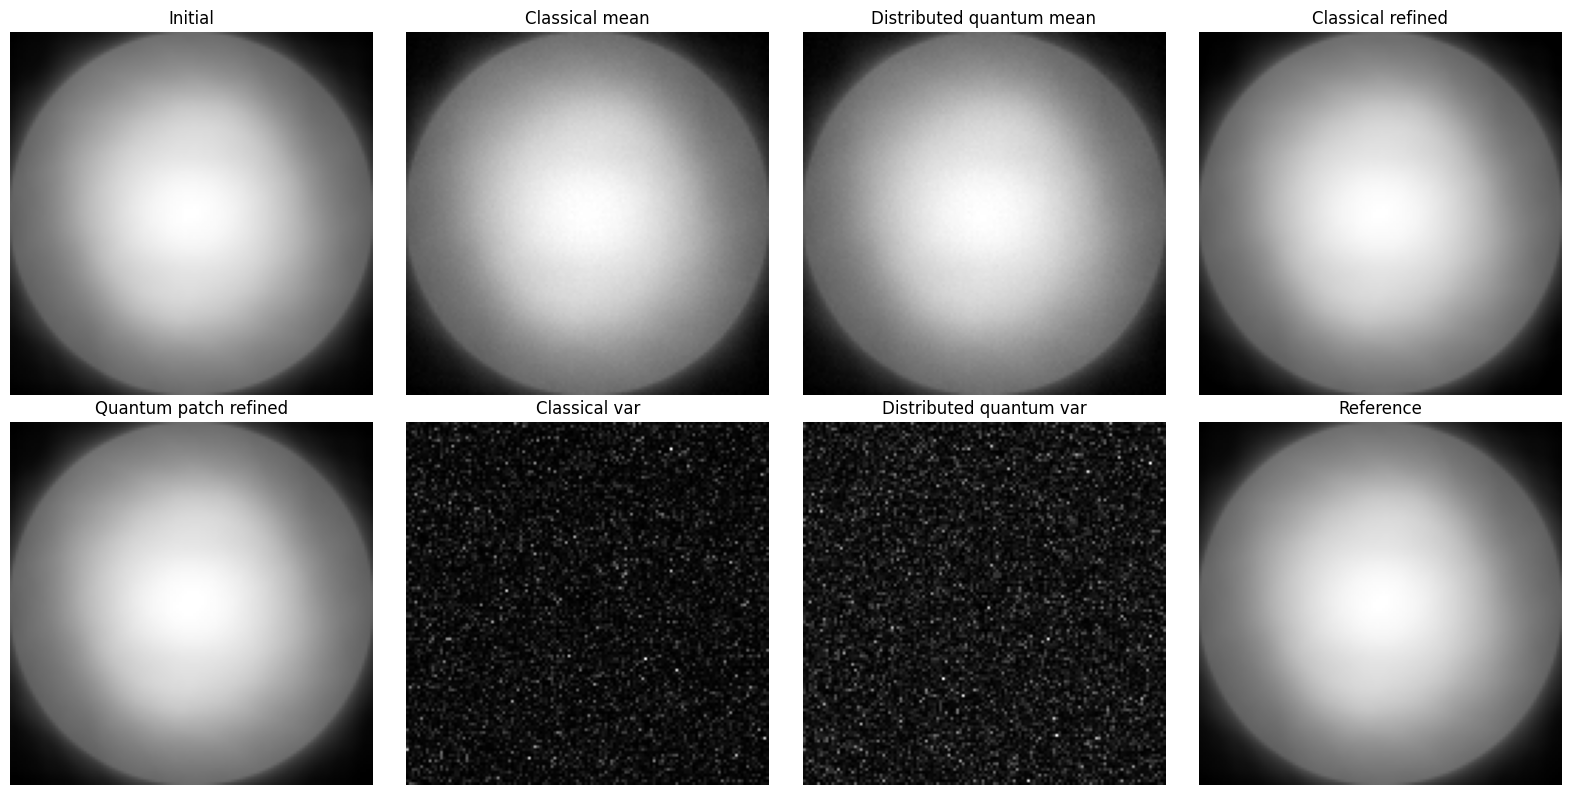

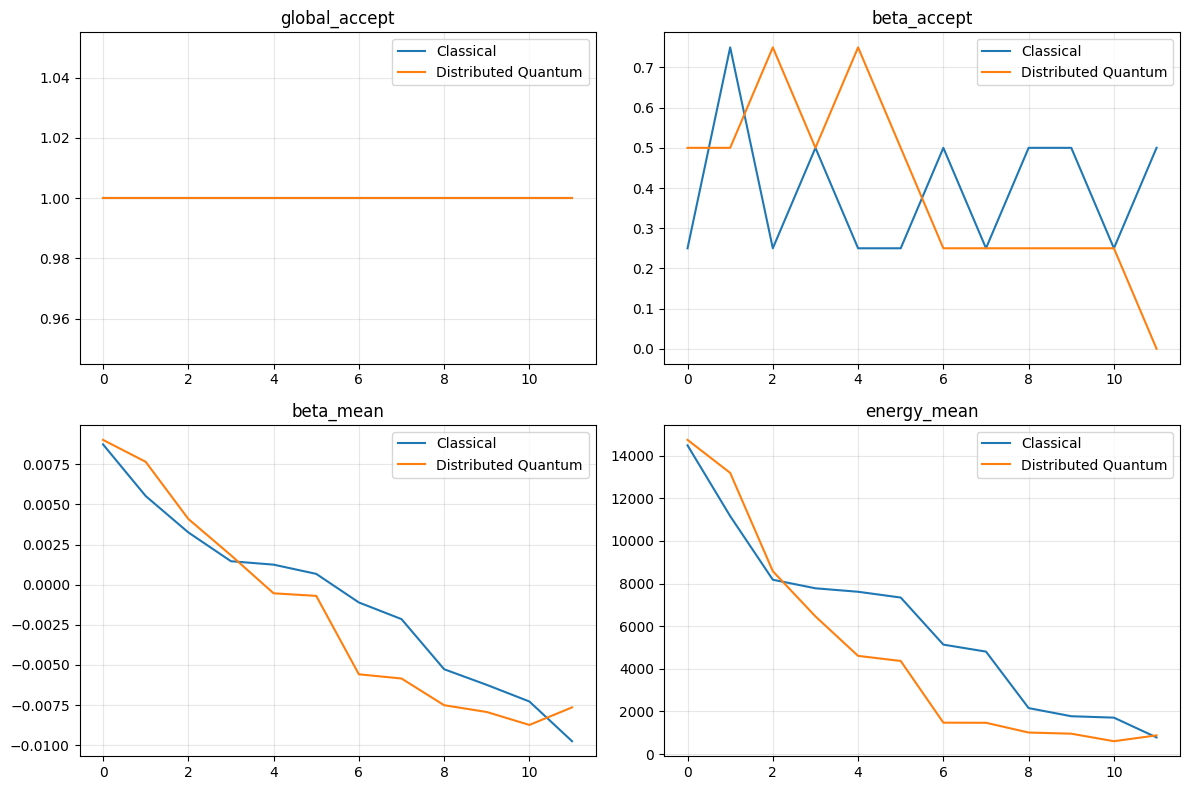

In [15]:

# =========================================================
# Block 14. Visualization dashboard
# =========================================================
if HAS_MPL:
    items = [
        ("Initial", x0[0,0]),
        ("Classical mean", classical_summary["mean"][0,0]),
        ("Distributed quantum mean", quantum_summary["mean"][0,0]),
        ("Classical refined", x_classical_refined[0,0]),
        ("Quantum patch refined", x_quantum_patch_refined[0,0]),
        ("Classical var", classical_summary["var"][0,0]),
        ("Distributed quantum var", quantum_summary["var"][0,0]),
    ]
    if x_ref is not None:
        items.append(("Reference", x_ref[0,0]))

    ncols = 4
    nrows = int(math.ceil(len(items) / ncols))
    fig = plt.figure(figsize=(4 * ncols, 4 * nrows))
    for i, (title, img) in enumerate(items, 1):
        ax = fig.add_subplot(nrows, ncols, i)
        ax.imshow(img.detach().cpu().numpy(), cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(12, 8))
    trace_names = ["global_accept", "beta_accept", "beta_mean", "energy_mean"]
    for i, name in enumerate(trace_names, 1):
        ax = fig.add_subplot(2, 2, i)
        ax.plot(classical_trace[name], label="Classical")
        ax.plot(quantum_trace[name], label="Distributed Quantum")
        ax.set_title(name)
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


,Metric,Value
0,beta_mean_classical,0.002599
1,beta_mean_quantum_distributed,-0.006546
2,energy_mean_classical,3388.418701
3,energy_mean_quantum_distributed,1311.096069
4,uncertainty_mean_classical,0.000000
5,uncertainty_mean_quantum_distributed,0.000000
6,initial_rmse_vs_full,0.002514
7,initial_psnr_vs_full,51.991523
8,initial_ssim_vs_full,0.999978
9,classical_refined_rmse_vs_full,0.011343


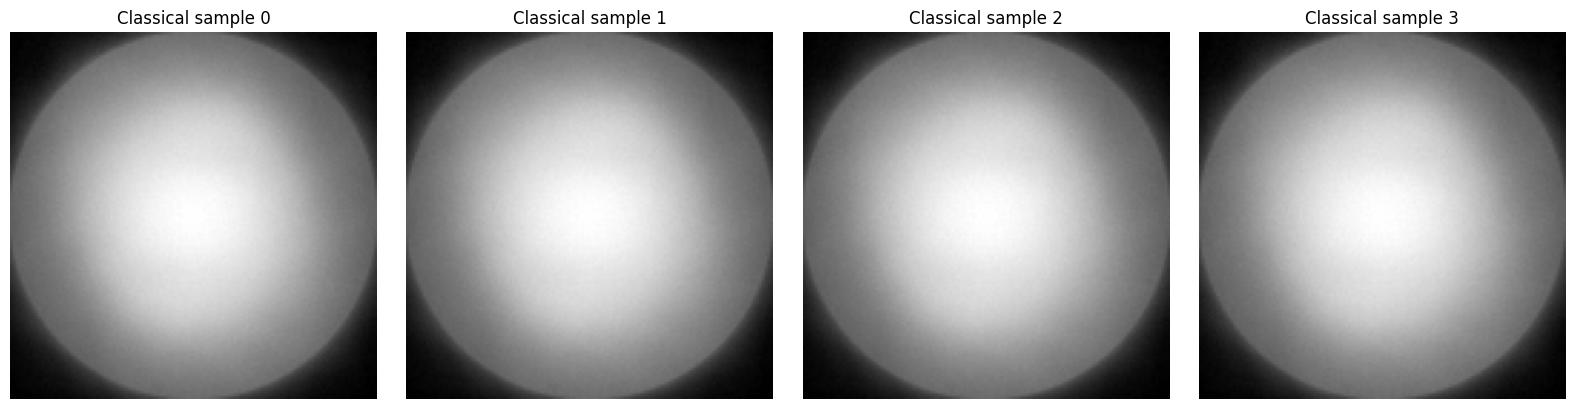

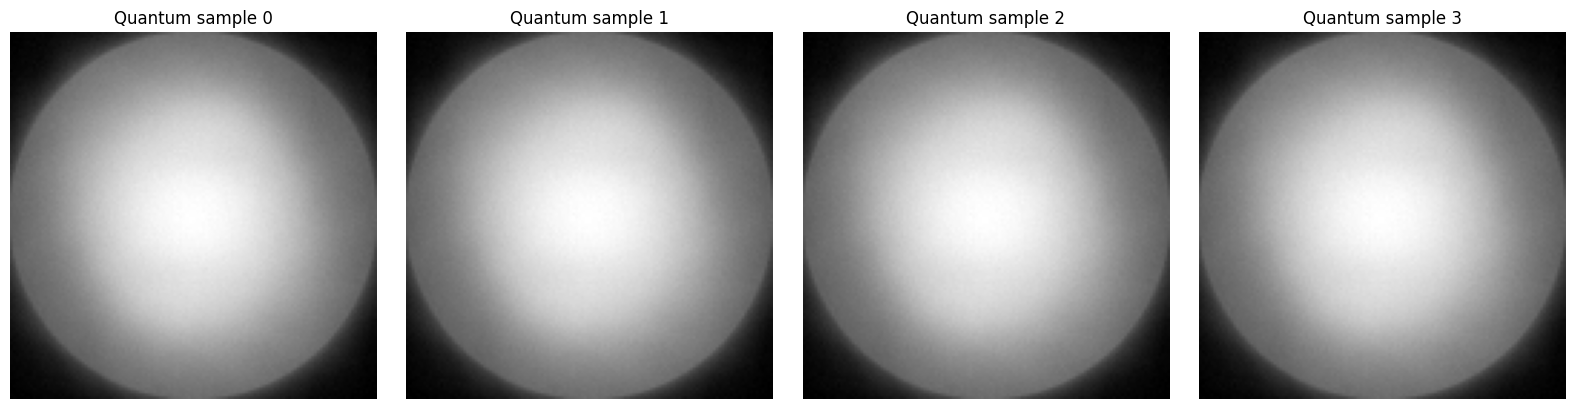

,Image,Blockiness(32)
0,Initial,0.007478
1,Classical refined,0.007496
2,Quantum patch refined,0.007555


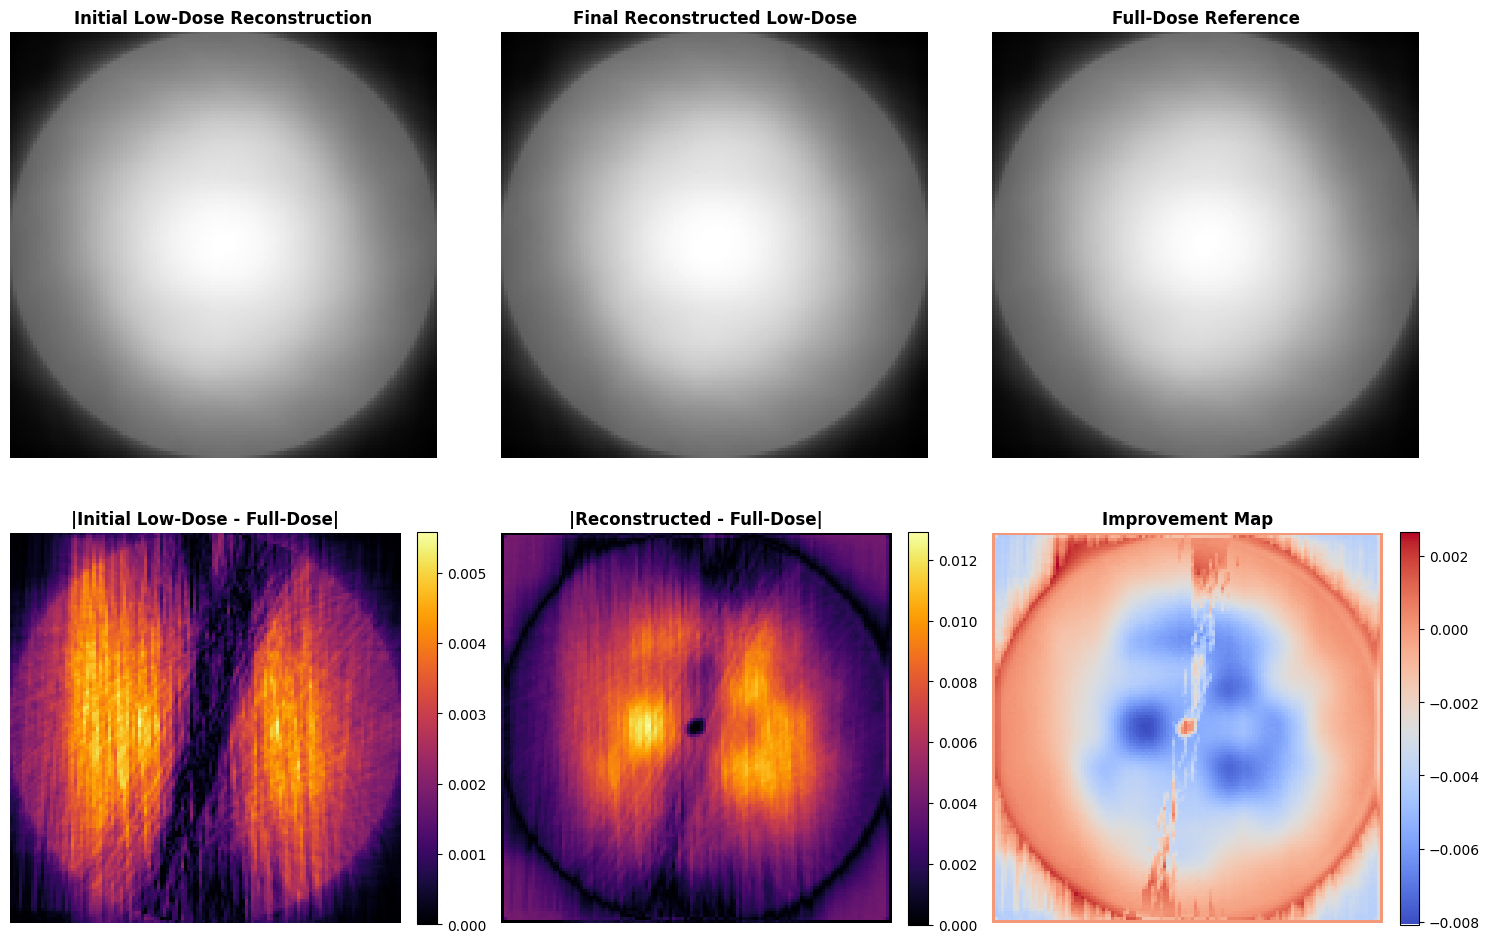

,Comparison,RMSE,PSNR,SSIM
0,Initial Low-Dose vs Full-Dose,0.002514,51.991523,0.999978
1,Final Reconstructed vs Full-Dose,0.005055,45.926196,0.999884


In [16]:

# =========================================================
# Block 15. Scientific result interpretation
# =========================================================
summary_df = pd.DataFrame([{"Metric": k, "Value": v} for k, v in metrics.items()])
display(summary_df.style.background_gradient(cmap="viridis", subset=["Value"]).set_caption("Comparison Summary Table").format({"Value": "{:.6f}"}))

def show_sample_grid(samples, title, n_show=4):
    if not HAS_MPL:
        return
    n = min(n_show, samples.shape[0])
    fig = plt.figure(figsize=(4 * n, 4))
    for i in range(n):
        ax = fig.add_subplot(1, n, i + 1)
        ax.imshow(samples[i,0].detach().cpu().numpy(), cmap="gray")
        ax.set_title(f"{title} sample {i}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_grid(classical_samples, "Classical")
show_sample_grid(quantum_samples, "Quantum")

def blockiness_score(x: torch.Tensor, block: int) -> float:
    img = x[0,0]
    h, w = img.shape
    score = 0.0
    count = 0
    for c in range(block, w, block):
        score += torch.mean(torch.abs(img[:, c] - img[:, c-1])).item()
        count += 1
    for r in range(block, h, block):
        score += torch.mean(torch.abs(img[r, :] - img[r-1, :])).item()
        count += 1
    return score / max(count, 1)

diag_df = pd.DataFrame([
    {"Image": "Initial", "Blockiness(32)": blockiness_score(x0, 32)},
    {"Image": "Classical refined", "Blockiness(32)": blockiness_score(x_classical_refined, 32)},
    {"Image": "Quantum patch refined", "Blockiness(32)": blockiness_score(x_quantum_patch_refined, 32)},
])
display(diag_df.style.background_gradient(cmap="magma", subset=["Blockiness(32)"]).set_caption("Blockiness Diagnostic").format({"Blockiness(32)": "{:.6f}"}))

if HAS_MPL and x_ref is not None:
    fig = plt.figure(figsize=(15, 10))

    ax = fig.add_subplot(2, 3, 1)
    ax.imshow(x0[0,0].detach().cpu().numpy(), cmap="gray")
    ax.set_title("Initial Low-Dose Reconstruction", fontweight="bold")
    ax.axis("off")

    ax = fig.add_subplot(2, 3, 2)
    ax.imshow(x_quantum_patch_refined[0,0].detach().cpu().numpy(), cmap="gray")
    ax.set_title("Final Reconstructed Low-Dose", fontweight="bold")
    ax.axis("off")

    ax = fig.add_subplot(2, 3, 3)
    ax.imshow(x_ref[0,0].detach().cpu().numpy(), cmap="gray")
    ax.set_title("Full-Dose Reference", fontweight="bold")
    ax.axis("off")

    err_init = torch.abs(x0 - x_ref)
    err_final = torch.abs(x_quantum_patch_refined - x_ref)
    improvement = err_init - err_final

    ax = fig.add_subplot(2, 3, 4)
    im = ax.imshow(err_init[0,0].detach().cpu().numpy(), cmap="inferno")
    ax.set_title("|Initial Low-Dose - Full-Dose|", fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = fig.add_subplot(2, 3, 5)
    im = ax.imshow(err_final[0,0].detach().cpu().numpy(), cmap="inferno")
    ax.set_title("|Reconstructed - Full-Dose|", fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = fig.add_subplot(2, 3, 6)
    im = ax.imshow(improvement[0,0].detach().cpu().numpy(), cmap="coolwarm")
    ax.set_title("Improvement Map", fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    final_compare_df = pd.DataFrame([
        {
            "Comparison": "Initial Low-Dose vs Full-Dose",
            "RMSE": rmse(x0, x_ref),
            "PSNR": psnr(x0, x_ref),
            "SSIM": ssim_global(x0, x_ref),
        },
        {
            "Comparison": "Final Reconstructed vs Full-Dose",
            "RMSE": rmse(x_quantum_patch_refined, x_ref),
            "PSNR": psnr(x_quantum_patch_refined, x_ref),
            "SSIM": ssim_global(x_quantum_patch_refined, x_ref),
        },
    ])

    display(
        final_compare_df.style
        .background_gradient(cmap="viridis", subset=["RMSE", "PSNR", "SSIM"])
        .set_caption("Final Low-Dose / Reconstructed / Full-Dose Comparison")
        .format({"RMSE": "{:.6f}", "PSNR": "{:.6f}", "SSIM": "{:.6f}"})
    )


In [17]:

# =========================================================
# Block 16. Save outputs
# =========================================================
save_dir = Path(load_cfg.save_dir)
save_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    save_dir / "hybrid_ct_clean_outputs.npz",
    low_sino_2d=low_sino_2d,
    full_sino_2d=None if full_sino_2d is None else full_sino_2d,
    x0=x0.detach().cpu().numpy(),
    x_ref=None if x_ref is None else x_ref.detach().cpu().numpy(),
    classical_samples=classical_samples.detach().cpu().numpy(),
    quantum_samples=quantum_samples.detach().cpu().numpy(),
    classical_mean=classical_summary["mean"].detach().cpu().numpy(),
    quantum_mean=quantum_summary["mean"].detach().cpu().numpy(),
    classical_var=classical_summary["var"].detach().cpu().numpy(),
    quantum_var=quantum_summary["var"].detach().cpu().numpy(),
    x_classical_refined=x_classical_refined.detach().cpu().numpy(),
    x_quantum_patch_refined=x_quantum_patch_refined.detach().cpu().numpy(),
    q_patch_gates=q_patch_gates.detach().cpu().numpy(),
)

with open(save_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

with open(save_dir / "config.json", "w", encoding="utf-8") as f:
    json.dump({
        "projection_load": asdict(load_cfg),
        "geometry": asdict(geom),
        "sampler": asdict(sampler_cfg),
        "runtime": asdict(runtime_cfg),
    }, f, indent=2)

if quantum_assist.last_distributed_results is not None:
    with open(save_dir / "last_distributed_results.json", "w", encoding="utf-8") as f:
        json.dump(quantum_assist.last_distributed_results, f, indent=2)

print("saved to:", save_dir.resolve())
print("files:", [p.name for p in save_dir.iterdir()])


saved to: /home/jovyan/work/sqk-qmc-qgan/outputs_hybrid_ct_160q_async3
files: ['metrics.json', 'config.json', 'hybrid_ct_clean_outputs.npz', 'last_distributed_results.json', 'quantum_exec_log_160q_async3.jsonl']
